# CNOT ⊗ I with GRAPE


In [12]:
import json, os
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from qutip.control.pulseoptim import optimize_pulse_unitary

np.set_printoptions(precision=6, suppress=True)

# settings
HYPERFINE_MODEL = "full"      # "full" | "secular"
CONTROL_MODE = "e_plus_n1"    # "electron_only" | "e_plus_n1"

Ts = [3e-6, 4e-6, 5e-6, 6e-6, 7, 8e-6, 9e-6, 10e-6]
n_ts_scout, max_iter_scout, max_wall_scout, seeds_scout = 800, 40, 25, [0,1,2,3,4,5]
n_ts_refine, max_iter_refine, max_wall_refine, seeds_refine = 2000, 120, 180, [0,1,2]

mix_thresh, comm_thresh, dsec_thresh = 5e-2, 1e-1, 1e-1
lam_mix, lam_comm, lam_dsec = 2.0, 0.5, 0.5

gamma_e_hz, gamma_n_hz, B0 = 28.024e9, 3.077e6, 1.33
A1_hz, A2_hz = 0.2e6, 0.15e6
B1_bound_T = 0.04

twopi = 2*np.pi
gamma_e, gamma_n = twopi*gamma_e_hz, twopi*gamma_n_hz
A1, A2 = twopi*A1_hz, twopi*A2_hz


In [13]:
def embed(op, which):
    ops = [qt.qeye(2), qt.qeye(2), qt.qeye(2)]
    ops[which] = op
    return qt.tensor(ops)

sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
Sx, Sy, Sz = embed(sx,0), embed(sy,0), embed(sz,0)
Ix1, Iy1, Iz1 = embed(sx,1), embed(sy,1), embed(sz,1)
Ix2, Iy2, Iz2 = embed(sx,2), embed(sy,2), embed(sz,2)

P0_n2 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.basis(2,0)*qt.basis(2,0).dag())
P1_n2 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.basis(2,1)*qt.basis(2,1).dag())
Z_n2 = P0_n2 - P1_n2

H_zeeman = -(gamma_e*B0)*Sz - (gamma_n*B0)*(Iz1 + Iz2)
if HYPERFINE_MODEL == "full":
    H_hf1 = A1*(Sx*Ix1 + Sy*Iy1 + Sz*Iz1)
    H_hf2 = A2*(Sx*Ix2 + Sy*Iy2 + Sz*Iz2)
elif HYPERFINE_MODEL == "secular":
    H_hf1 = A1*(Sz*Iz1)
    H_hf2 = A2*(Sz*Iz2)
else:
    raise ValueError("HYPERFINE_MODEL")

H0 = H_zeeman + H_hf1 + H_hf2

if CONTROL_MODE == "electron_only":
    Hc = [Sx, Sy]
elif CONTROL_MODE == "e_plus_n1":
    Hc = [Sx, Sy, Ix1, Iy1]
else:
    raise ValueError("CONTROL_MODE")

def cnot_2q():
    return qt.Qobj(np.array([[1,0,0,0],
                             [0,1,0,0],
                             [0,0,0,1],
                             [0,0,1,0]], dtype=complex), dims=[[2,2],[2,2]])

U0 = qt.qeye([2,2,2])
U_targ = qt.tensor(cnot_2q(), qt.qeye(2))
print("n_ctrls:", len(Hc), "| target dims:", U_targ.dims)


n_ctrls: 4 | target dims: [[2, 2, 2], [2, 2, 2]]


In [14]:
def simulate_piecewise(H0, Hc, amps, T):
    n_ts = amps.shape[0]
    dt = T / n_ts
    U = qt.qeye([2,2,2])
    for j in range(n_ts):
        Hj = H0
        for k in range(len(Hc)):
            Hj = Hj + amps[j,k]*Hc[k]
        U = (-1j*Hj*dt).expm() @ U
    return U

def gate_fsq(Ut, U):
    d = Ut.shape[0]
    return float(abs((Ut.dag() @ U).tr()) / d) ** 2

def sector_gate(U, sector):
    basis_2q = [qt.tensor(qt.basis(2,i), qt.basis(2,j)) for i in range(2) for j in range(2)]
    ket_n2 = qt.basis(2, sector)
    M = np.zeros((4,4), dtype=complex)
    for a, va in enumerate(basis_2q):
        bra = qt.tensor(va, ket_n2).dag()
        for b, vb in enumerate(basis_2q):
            ket = qt.tensor(vb, ket_n2)
            M[a,b] = bra @ (U @ ket)
    return M

def spectator_metrics(U):
    L01 = (P0_n2 @ U @ P1_n2).norm()
    L10 = (P1_n2 @ U @ P0_n2).norm()
    comm = (U @ Z_n2 - Z_n2 @ U).norm()
    U0_eff = sector_gate(U, 0)
    U1_eff = sector_gate(U, 1)
    phi = np.angle(np.trace(np.conjugate(U0_eff.T) @ U1_eff))
    dsec = np.linalg.norm(U0_eff - np.exp(-1j*phi)*U1_eff)
    return float(L01), float(L10), float(comm), float(dsec)

def feasible(L01, L10, comm, dsec):
    return (L01 < mix_thresh and L10 < mix_thresh and comm < comm_thresh and dsec < dsec_thresh)


In [15]:
def run_once(T, n_ts, max_iter, max_wall_time, seed, init_scale=0.2, fid_err_targ=1e-2):
    np.random.seed(seed)
    tau = np.full(n_ts, T/n_ts)

    res = optimize_pulse_unitary(
        H_d=H0, H_c=Hc, U_0=U0, U_targ=U_targ,
        num_tslots=n_ts, evo_time=T, tau=tau,
        amp_lbound=-float(B1_bound_T), amp_ubound=float(B1_bound_T),
        fid_err_targ=fid_err_targ,
        max_iter=max_iter, max_wall_time=max_wall_time,
        alg="GRAPE",
        init_pulse_type="RND",
        pulse_scaling=float(init_scale*B1_bound_T),
        pulse_offset=0.0,
        log_level=0,
    )

    amps = res.final_amps
    U = simulate_piecewise(H0, Hc, amps, T)
    Fsq = gate_fsq(U_targ, U)
    L01, L10, comm, dsec = spectator_metrics(U)
    score = Fsq - lam_mix*(L01+L10) - lam_comm*comm - lam_dsec*dsec
    return {
        "res": res, "amps": amps, "U": U, "T": T, "seed": seed,
        "Fsq": Fsq, "L01": L01, "L10": L10, "comm": comm, "dsec": dsec,
        "feasible": feasible(L01, L10, comm, dsec), "score": score
    }

def run_multistart(T, n_ts, max_iter, max_wall_time, seeds, init_scale=0.2, fid_err_targ=1e-2):
    best = None
    rows = []
    for sd in seeds:
        out = run_once(T, n_ts, max_iter, max_wall_time, sd, init_scale, fid_err_targ)
        rows.append(out)
        if best is None or out["score"] > best["score"]:
            best = out
    return best, rows


In [16]:
print("=== scout ===")
sweep = []
for T in Ts:
    bestT, _ = run_multistart(T, n_ts_scout, max_iter_scout, max_wall_scout, seeds_scout, init_scale=0.2, fid_err_targ=1e-2)
    sweep.append(bestT)
    print(f"T={T*1e6:6.1f} us | Fsq={bestT['Fsq']:.6f} | fid_err={bestT['res'].fid_err:.3e} | "
          f"L01={bestT['L01']:.3e} | L10={bestT['L10']:.3e} | comm={bestT['comm']:.3e} | "
          f"dsec={bestT['dsec']:.3e} | seed={bestT['seed']} | feasible={bestT['feasible']}")

feasible_list = [x for x in sweep if x["feasible"]]
best_scout = max(feasible_list, key=lambda x: x["score"]) if feasible_list else max(sweep, key=lambda x: x["score"])

print("\nbest scout:")
print(f"T={best_scout['T']*1e6:.1f} us | seed={best_scout['seed']} | feasible={best_scout['feasible']}")
print(f"Fsq={best_scout['Fsq']:.6f} | fid_err={best_scout['res'].fid_err:.3e} | "
      f"L01={best_scout['L01']:.3e} | L10={best_scout['L10']:.3e} | comm={best_scout['comm']:.3e} | dsec={best_scout['dsec']:.3e}")


=== scout ===
T=   3.0 us | Fsq=0.010600 | fid_err=8.970e-01 | L01=5.296e-05 | L10=5.296e-05 | comm=2.118e-04 | dsec=1.236e+00 | seed=4 | feasible=False
T=   4.0 us | Fsq=0.003107 | fid_err=9.443e-01 | L01=6.168e-05 | L10=6.168e-05 | comm=2.467e-04 | dsec=2.351e+00 | seed=0 | feasible=False
T=   5.0 us | Fsq=0.013171 | fid_err=8.852e-01 | L01=6.556e-05 | L10=6.556e-05 | comm=2.622e-04 | dsec=2.501e-09 | seed=1 | feasible=True
T=   6.0 us | Fsq=0.029704 | fid_err=8.277e-01 | L01=6.305e-05 | L10=6.305e-05 | comm=2.522e-04 | dsec=2.351e+00 | seed=0 | feasible=False
T=7000000.0 us | Fsq=0.005584 | fid_err=9.253e-01 | L01=6.276e-05 | L10=6.276e-05 | comm=2.510e-04 | dsec=3.388e-03 | seed=4 | feasible=True
T=   8.0 us | Fsq=0.096574 | fid_err=6.892e-01 | L01=3.947e-05 | L10=3.947e-05 | comm=1.579e-04 | dsec=1.236e+00 | seed=5 | feasible=False
T=   9.0 us | Fsq=0.237057 | fid_err=5.131e-01 | L01=2.466e-05 | L10=2.466e-05 | comm=9.865e-05 | dsec=2.351e+00 | seed=2 | feasible=False
T=  10.0 us 

In [17]:
print("\n=== refine ===")
if not best_scout["feasible"]:
    chosen = best_scout
    source = "SCOUT"
    print("skip refinement")
else:
    best_ref, _ = run_multistart(best_scout["T"], n_ts_refine, max_iter_refine, max_wall_refine,
                                 seeds_refine, init_scale=0.2, fid_err_targ=1e-3)
    chosen = best_ref
    source = "REFINE"
    print(f"T={chosen['T']*1e6:.1f} us | seed={chosen['seed']} | feasible={chosen['feasible']}")
    print(f"Fsq={chosen['Fsq']:.6f} | fid_err={chosen['res'].fid_err:.3e} | "
          f"L01={chosen['L01']:.3e} | L10={chosen['L10']:.3e} | comm={chosen['comm']:.3e} | dsec={chosen['dsec']:.3e}")



=== refine ===
T=10.0 us | seed=1 | feasible=True
Fsq=0.155731 | fid_err=6.054e-01 | L01=1.589e-05 | L10=1.589e-05 | comm=6.355e-05 | dsec=4.719e-09


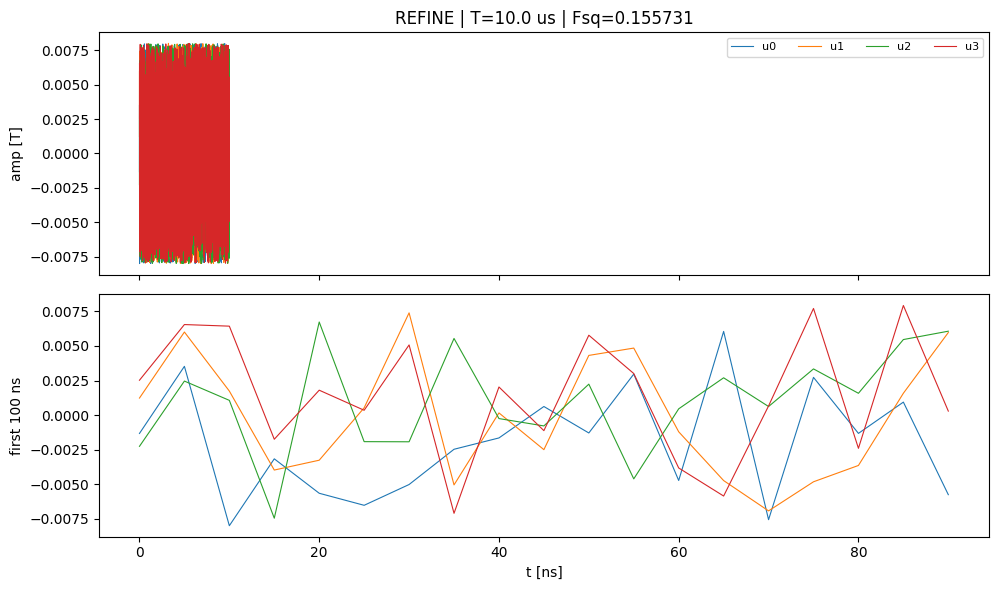

In [18]:
amps = chosen["amps"]
T = chosen["T"]
tlist = np.linspace(0, T, amps.shape[0], endpoint=False)

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for k in range(amps.shape[1]):
    ax[0].plot(tlist*1e6, amps[:,k], lw=0.8, label=f"u{k}")
ax[0].set_ylabel("amp [T]")
ax[0].legend(ncol=min(4, amps.shape[1]), fontsize=8)
ax[0].set_title(f"{source} | T={T*1e6:.1f} us | Fsq={chosen['Fsq']:.6f}")

zoom = max(10, int(0.1e-6 / T * len(tlist)))
for k in range(amps.shape[1]):
    ax[1].plot(tlist[:zoom]*1e9, amps[:zoom,k], lw=0.8)
ax[1].set_xlabel("t [ns]")
ax[1].set_ylabel("first 100 ns")
plt.tight_layout()
plt.show()


In [19]:
os.makedirs("artifacts", exist_ok=True)
np.save("artifacts/amps_opt.npy", chosen["amps"])
with open("artifacts/meta.json", "w") as f:
    json.dump({
        "source": source,
        "HYPERFINE_MODEL": HYPERFINE_MODEL,
        "CONTROL_MODE": CONTROL_MODE,
        "T": chosen["T"],
        "seed": chosen["seed"],
        "Fsq": chosen["Fsq"],
        "fid_err_reported": float(chosen["res"].fid_err),
        "L01": chosen["L01"],
        "L10": chosen["L10"],
        "comm": chosen["comm"],
        "sector_diff": chosen["dsec"],
        "feasible": bool(chosen["feasible"]),
        "n_ctrls": len(Hc),
        "B1_bound_T": float(B1_bound_T),
        "A1_hz": float(A1_hz),
        "A2_hz": float(A2_hz),
        "B0": float(B0)
    }, f, indent=2)

print("saved artifacts/amps_opt.npy and artifacts/meta.json")


saved artifacts/amps_opt.npy and artifacts/meta.json
